In [1]:
import pathlib
import sys
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from seagliderOG1 import convertOG1, writers
from tqdm import tqdm
import xarray as xr
import importlib
import numpy as np

script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
sys.path.append(str(parent_dir))
from dissipationSML import reading, plotting, tools

In [2]:
importlib.reload(reading)
importlib.reload(plotting)
importlib.reload(tools)

<module 'dissipationSML.tools' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools.py'>

## 1. Chose the glider and the mission

In [ ]:
# Example usage
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
selected_glider = reading.interactive_glider_selection(yaml_path)

Dropdown(description='Select Glider:', options=('005', '012', '014', '016', '101', '102', '103', '104', '105')…

Dropdown(description='Select Mission:', options=('06/08 (dives: 386)', '06/09 (dives: 464)', '11/08 (dives: 48…

Button(description='Confirm Selection', style=ButtonStyle())

Selected Path: https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/005/20080606/


In [4]:
### From the chosen glider mission, the important variables are taken. The destination folder is also selected here.
### The mission path gives the exact path to the dedicated mission of the chosen glider. It will be used later to save and load the concatenated/converted data
data_path = selected_glider['path']
end_profile = selected_glider['dives']
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"
mission_path = destination_folder + '/' + selected_glider['glider'] + '/' + selected_glider['mission']

### 1.1 Load the data into a list of .nc files and then convert into OG1 format which is also concatenating the data. 
### The data is saved at the mission path 

In [5]:
### All datasets from the glider mission are downloaded and then loaded as .nc file into one list
datasets = reading.read_basestation(data_path, destination_path=destination_folder, start_profile=1, end_profile=end_profile)


File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/p0050001_20080606.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/p0050002_20080606.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/p0050003_20080606.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/p0050004_20080607.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/p0050005_20080607.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/p0050006_20080607.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/p0050007_20080607.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/p0050008_20080607.nc
File already exists: /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/005/20080606/p0050009_20080607.nc
File already exists: /Users/tillmorit

In [269]:
variables_needed = ['LONGITUDE','LATITUDE','TIME','DEPTH','GLIDER_VERT_VELO_MODEL','THETA','TEMP',
                    'GLIDE_SPEED','SIGTHETA','SIGMA_T','PSAL','PRES','GLIDER_HORZ_VELO_MODEL','DIVE_NUMBER','PROFILE_NUMBER','PSAL_RAW','TEMP_RAW']
### convert the dataset to OG1 format only with the variables needed
ds = reading.convert_with_variables(datasets,variables_needed)
### calculate potential density from raw data and add it to the dataset
ds = tools.add_pot_density_from_raw_data(ds)

Converting datasets to OG1 format: 100%|██████████| 421/421 [03:06<00:00,  2.26it/s]


In [270]:
### save the OG1 dataset at the destination folder
writers.save_dataset(ds, mission_path + '/all_data_OG1.nc')

True

### 2. Load the dataset and do some plotting

In [6]:
ds = xr.open_dataset(mission_path + '/all_data_OG1.nc')

In [7]:
ds

<xarray.Dataset> Size: 35MB
Dimensions:                 (N_MEASUREMENTS: 332364)
Coordinates:
    LONGITUDE               (N_MEASUREMENTS) float64 3MB ...
    LATITUDE                (N_MEASUREMENTS) float64 3MB ...
    TIME                    (N_MEASUREMENTS) datetime64[ns] 3MB ...
    DEPTH                   (N_MEASUREMENTS) float64 3MB ...
Dimensions without coordinates: N_MEASUREMENTS
Data variables: (12/15)
    GLIDER_VERT_VELO_MODEL  (N_MEASUREMENTS) float32 1MB ...
    THETA                   (N_MEASUREMENTS) float32 1MB ...
    TEMP                    (N_MEASUREMENTS) float32 1MB ...
    GLIDE_SPEED             (N_MEASUREMENTS) float32 1MB ...
    SIGTHETA                (N_MEASUREMENTS) float32 1MB ...
    SIGMA_T                 (N_MEASUREMENTS) float32 1MB ...
    ...                      ...
    DIVE_NUMBER             (N_MEASUREMENTS) int32 1MB ...
    PROFILE_NUMBER          (N_MEASUREMENTS) float64 3MB ...
    PSAL_RAW                (N_MEASUREMENTS) float32 1MB ...
    TEMP_RAW                (N_MEASUREMENTS) float32 1MB ...
    SIGTHETA_RAW            (N_MEASUREMENTS) float64 3MB ...
    SIGMA_T_RAW             (N_MEASUREMENTS) float64 3MB ...
Attributes: (12/39)
    title:                                      OceanGliders trajectory file
    id:                                         sg005_20080606T180738_delayed
    platform:                                   sub-surface gliders
    platform_vocabulary:                        https://vocab.nerc.ac.uk/coll...
    naming_authority:                           edu.washington.apl
    institution:                                School of Oceanography\nUnive...
    ...                                         ...
    acknowledgment:                             National Science Foundation, ...
    license:                                    These data may be redistribut...
    disclaimer:                                 Data provided AS-IS.
    file_version:                               2.71
    keywords:                                   Water Temperature, Conductivi...
    keywords_vocabulary:                        NASA/GCMD Earth Science Keywo...

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


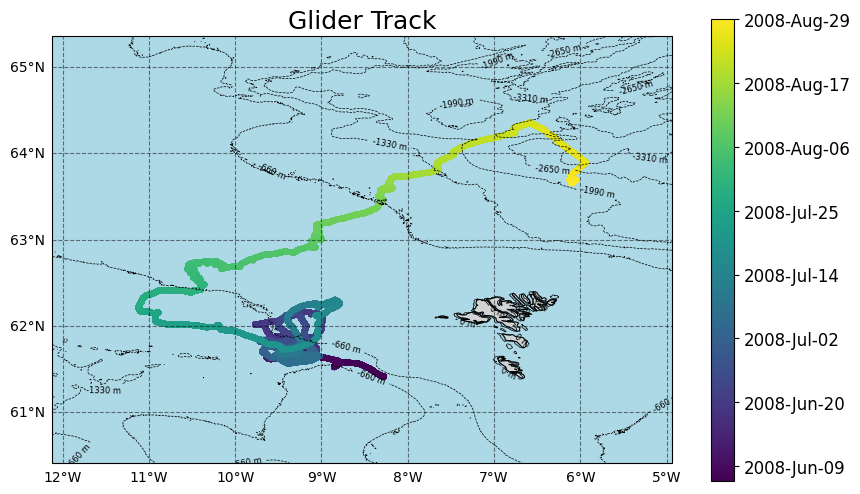

In [9]:
### plot the glider track
importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds)
display(fig)
### save the figure
#fig.savefig(mission_path + '/glider_track.png', dpi=300)
del fig, ax

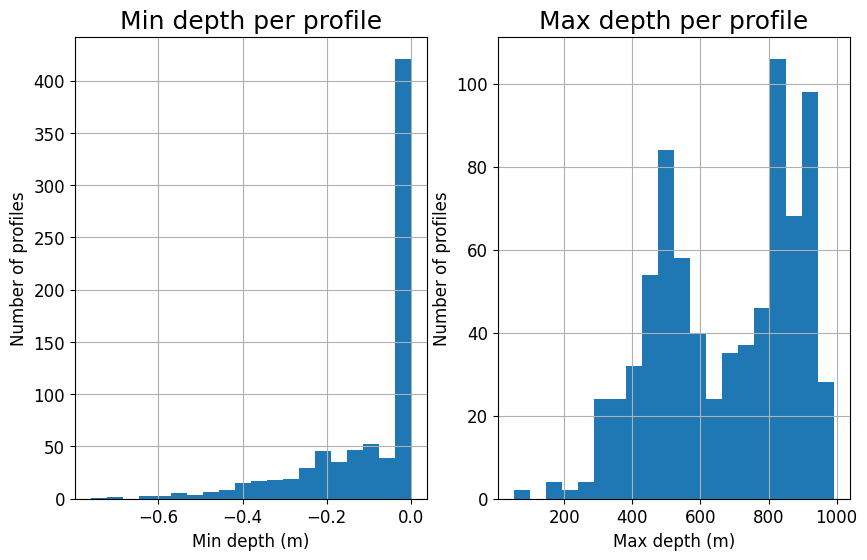

In [10]:
importlib.reload(plotting)
importlib.reload(tools)
fig, ax = plotting.plot_min_max_depth(ds)
display(fig)
#fig.savefig(mission_path + '/min_max_histogram.png', dpi=300)
del fig, ax


In [11]:
### make function with widgets to go through the profiles
importlib.reload(plotting)
importlib.reload(tools)
def plot_profile(profile_number, plot_raw):
    fig,ax1,ax2,ax3 = plotting.plot_profile(ds, profile_number, plot_raw)
    display(fig)
    del fig, ax1, ax2, ax3

profile_slider = widgets.IntSlider(value=1, min=1, max=ds.PROFILE_NUMBER.max(), description='Profile number')
raw_button = widgets.Checkbox(value=False, description='Raw data')
widgets.interactive(plot_profile, profile_number=profile_slider, plot_raw=raw_button)

interactive(children=(IntSlider(value=1, description='Profile number', max=772, min=1), Checkbox(value=False, …

In [12]:
importlib.reload(plotting)
def plot_resolution_histogram(profile_number):
    fig, ax = plotting.plot_vertical_resolution(ds, profile_number)
    display(fig)
    del fig, ax

profile_slider = widgets.IntSlider(value=1, min=1, max=ds.PROFILE_NUMBER.max(), description='Profile number')
widgets.interactive(plot_resolution_histogram, profile_number=profile_slider)

interactive(children=(IntSlider(value=1, description='Profile number', max=772, min=1), Output()), _dom_classe…

In [13]:
### make function with widgets to go through the profiles
importlib.reload(plotting)
importlib.reload(tools)
def plot_profile(profile_number, binning, use_raw,agg):
    fig,ax1,ax2,ax3 = plotting.plot_profile_binned(ds, profile_number, binning,use_raw, agg)
    display(fig)
    del fig, ax1, ax2, ax3

profile_slider = widgets.IntSlider(value=1, min=1, max=ds.PROFILE_NUMBER.max(), description='Profile number:')
binning_slider = widgets.IntSlider(value=2, min=1, max=20, description='Binning (m):')
raw_button = widgets.Checkbox(value=False, description='Use raw data')
agg_button = widgets.ToggleButtons(options=['mean', 'median'],description='Aggregation:',disabled=False,button_style='')

widgets.interactive(plot_profile, profile_number=profile_slider, binning=binning_slider, use_raw=raw_button, agg=agg_button)

interactive(children=(IntSlider(value=1, description='Profile number:', max=772, min=1), IntSlider(value=2, de…

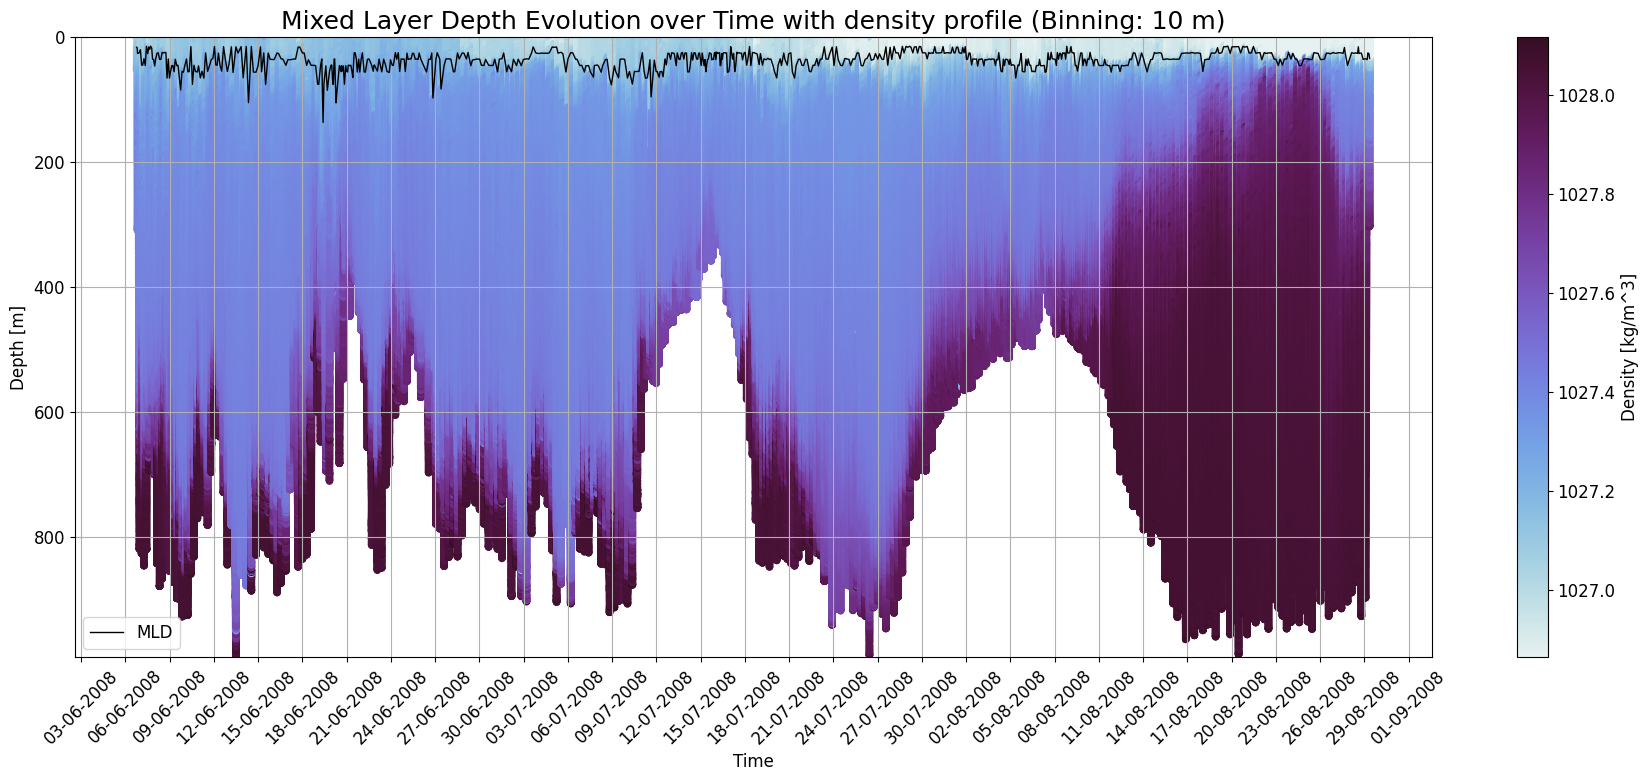

In [14]:
importlib.reload(plotting)
fig,ax = plotting.plot_MLD_evolution(ds,binning = 10,use_raw = True, plot_density= True)
display(fig)
#fig.savefig(mission_path + '/MLD_time_evolution.png', dpi=300)
del fig, ax

In [15]:
### cutting out profile numbers that are not needed
#ds = ds.isel(N_MEASUREMENTS=ds.PROFILE_NUMBER != 6)

In [16]:
importlib.reload(tools)
### add the MLD to the dataset for each profile
ds = tools.add_MLD_to_dataset(ds, use_bins=True, binning = 10, use_raw = True,agg='median')

Calculating and adding MLD for Profiles: 100%|██████████| 770/770 [00:59<00:00, 12.96profile/s]


In [17]:
# Create sliders for longitude and latitude
default_coords = [[-14.0, 63.5], # First corner
                  [-13, 64.5], # Second corner
                  [-7.5, 62], # Third corner
                  [-9, 61]] # Fourth corner

importlib.reload(plotting)
importlib.reload(tools)
# Create the interactive selector
get_region = plotting.interactive_region_selector(default_coords)

Button(description='Confirm Selection', style=ButtonStyle())

Output()

Region confirmed!


/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


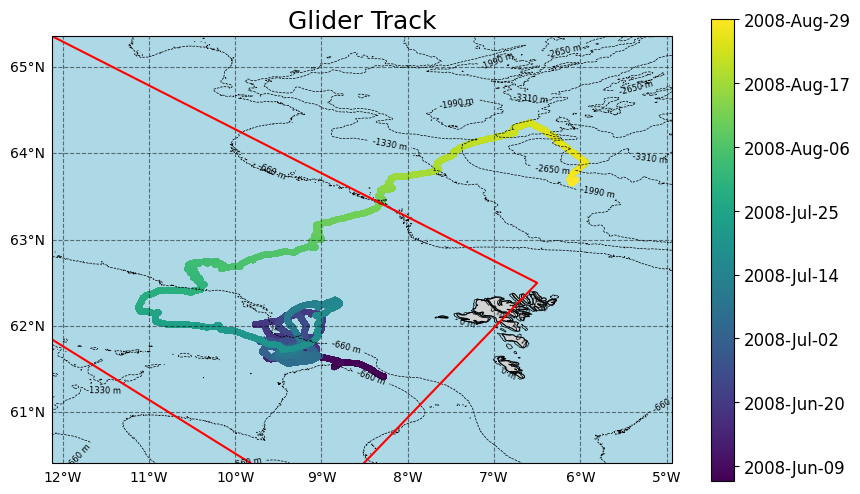

In [18]:
### get the coordinates of the region and plot it together with the glider track
region = get_region()

importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds)
region.plot(ax=ax, add_label=False, line_kws={'color': 'red'})
display(fig)
#fig.savefig(mission_path + '/glider_track_region.png', dpi=300)
del fig, ax

In [19]:
importlib.reload(tools)
ds_region = tools.cut_region(ds, region)

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


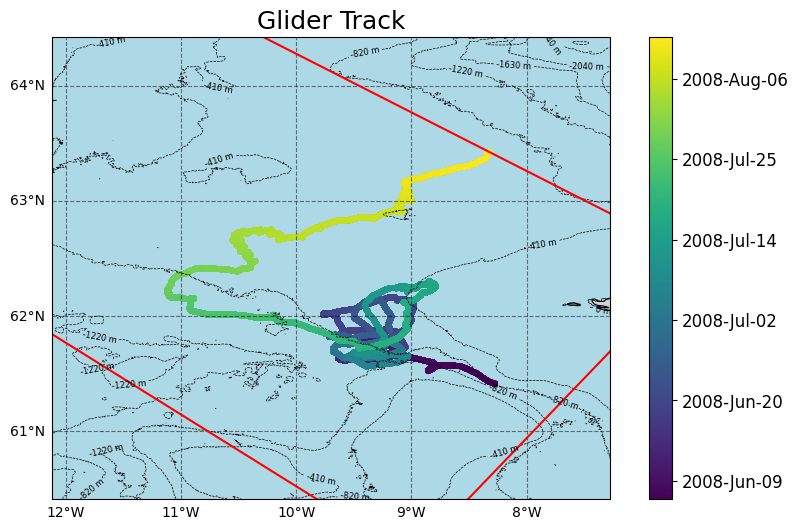

In [20]:
importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds_region)
region.plot(ax=ax, add_label=False, line_kws={'color': 'red'})
display(fig)
#fig.savefig(mission_path + '/glider_track_region.png', dpi=300)
del fig, ax

In [ ]:
### save the dataset with MLD
#writers.save_dataset(ds, mission_path + '/all_data_OG1_with_MLD.nc')